In [1]:
import numpy as np
from src.score import compute_pbf_score, compute_pbi_score
import matplotlib.pyplot as plt
from matplotlib import colormaps as cmaps

In [2]:
def plot_pbf(n_articles, n_summaries, true_bias):
  biases = np.array([-1, 0., 1.])

  # Generate all possible sets of biases (N, n_articles, n_summaries)
  all_biases = np.array(np.meshgrid(*[biases] * n_summaries * n_articles)).T.reshape(-1, n_articles, n_summaries)
  print(all_biases.shape)

  scores = []
  for bias in all_biases:
    scores.append(compute_pbf_score(true_bias, bias))

  print(scores)

  for bias, score in zip(all_biases, scores):
    print(bias, score)

  vmin = 0
  vmax = 1
  ticks = np.linspace(vmin, vmax, 11)
  
  fig = plt.figure()
  # Plot
  if n_articles == 1 and n_summaries == 2:
    im = plt.scatter(all_biases[:, 0, 0], all_biases[:, 0, 1], c=scores, vmin=vmin, vmax=vmax)
    cbar = plt.colorbar(im, ticks=ticks)
    plt.xlabel("Bias of summary 1")
    plt.ylabel("Bias of summary 2")
  elif n_summaries == 1 and n_articles == 2:
    im = plt.scatter(all_biases[:, 0, 0], all_biases[:, 1, 0], c=scores, vmin=vmin, vmax=vmax)
    cbar = plt.colorbar(im, ticks=ticks)
    plt.xlabel("Bias of article 1")
    plt.ylabel("Bias of article 2")
  elif n_summaries == 3 and n_articles == 1:
    # plot 3D
    ax = fig.add_subplot(111, projection='3d')
    sp = ax.scatter3D(all_biases[:, 0, 0], all_biases[:, 0, 1], all_biases[:, 0, 2], c=scores, cmap=cmaps['plasma'], vmin=vmin, vmax=vmax)
    plt.colorbar(sp, ticks=ticks)
    ax.set_xlabel("Bias of summary 1")
    ax.set_ylabel("Bias of summary 2")
    ax.set_zlabel("Bias of summary 3")
  elif n_summaries == 1 and n_articles == 3:
    # plot 3D
    ax = fig.add_subplot(111, projection='3d')
    sp = ax.scatter3D(all_biases[:, 0, 0], all_biases[:, 1, 0], all_biases[:, 2, 0], c=scores, cmap=cmaps['plasma'], vmin=vmin, vmax=vmax)
    plt.colorbar(sp, ticks=ticks)
    ax.set_xlabel("Bias of article 1")
    ax.set_ylabel("Bias of article 2")
    ax.set_zlabel("Bias of article 3")

  plt.title(f"PBF score for true bias {true_bias}")
  plt.show()
  plt.close()
  


(9, 2, 1)
[0.5, 0.3535533905932738, 0.5, 0.3535533905932738, 0.0, 0.3535533905932738, 0.5, 0.3535533905932738, 0.5]
[[-1.]
 [-1.]] 0.5
[[-1.]
 [ 0.]] 0.3535533905932738
[[-1.]
 [ 1.]] 0.5
[[ 0.]
 [-1.]] 0.3535533905932738
[[0.]
 [0.]] 0.0
[[0.]
 [1.]] 0.3535533905932738
[[ 1.]
 [-1.]] 0.5
[[1.]
 [0.]] 0.3535533905932738
[[1.]
 [1.]] 0.5


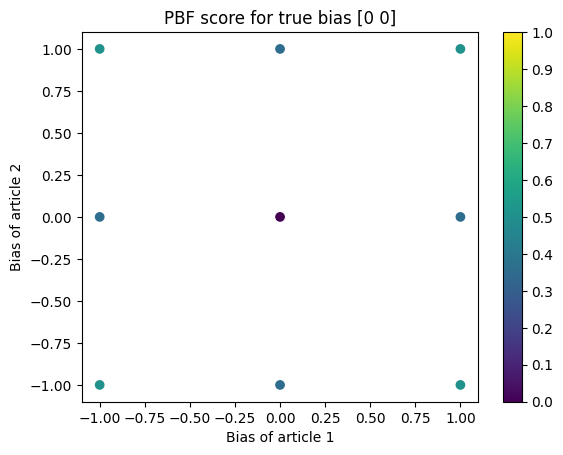

In [3]:
plot_pbf(2, 1, np.array([0, 0]))

(9, 1, 2)
[0.5, 0.3535533905932738, 0.5, 0.3535533905932738, 0.0, 0.3535533905932738, 0.5, 0.3535533905932738, 0.5]
[[-1. -1.]] 0.5
[[-1.  0.]] 0.3535533905932738
[[-1.  1.]] 0.5
[[ 0. -1.]] 0.3535533905932738
[[0. 0.]] 0.0
[[0. 1.]] 0.3535533905932738
[[ 1. -1.]] 0.5
[[1. 0.]] 0.3535533905932738
[[1. 1.]] 0.5


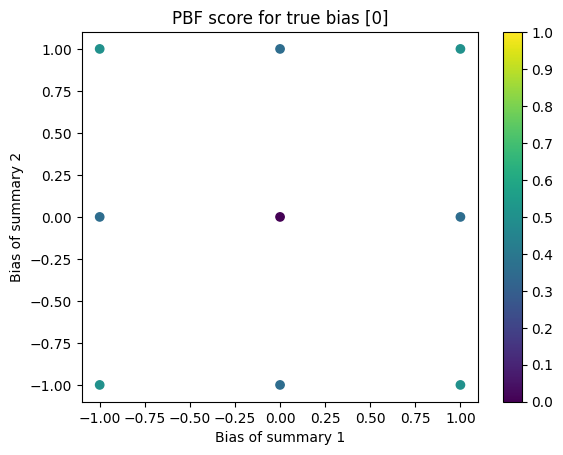

In [4]:
plot_pbf(1, 2, np.array([0]))


(9, 2, 1)
[1.0, 0.7905694150420949, 0.7071067811865476, 0.7905694150420949, 0.5, 0.3535533905932738, 0.7071067811865476, 0.3535533905932738, 0.0]
[[-1.]
 [-1.]] 1.0
[[-1.]
 [ 0.]] 0.7905694150420949
[[-1.]
 [ 1.]] 0.7071067811865476
[[ 0.]
 [-1.]] 0.7905694150420949
[[0.]
 [0.]] 0.5
[[0.]
 [1.]] 0.3535533905932738
[[ 1.]
 [-1.]] 0.7071067811865476
[[1.]
 [0.]] 0.3535533905932738
[[1.]
 [1.]] 0.0


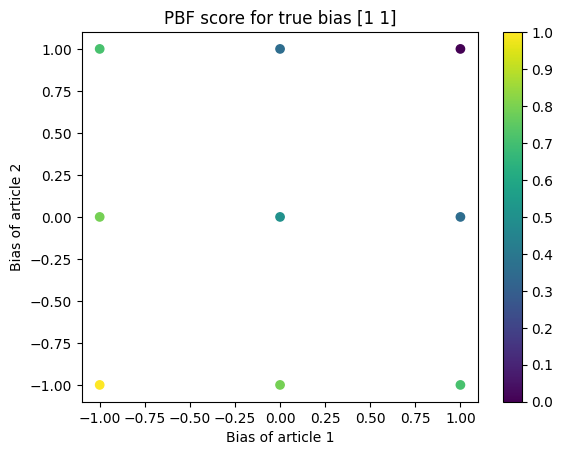

In [5]:
plot_pbf(2, 1, np.array([1, 1]))

(9, 1, 2)
[1.0, 0.7905694150420949, 0.7071067811865476, 0.7905694150420949, 0.5, 0.3535533905932738, 0.7071067811865476, 0.3535533905932738, 0.0]
[[-1. -1.]] 1.0
[[-1.  0.]] 0.7905694150420949
[[-1.  1.]] 0.7071067811865476
[[ 0. -1.]] 0.7905694150420949
[[0. 0.]] 0.5
[[0. 1.]] 0.3535533905932738
[[ 1. -1.]] 0.7071067811865476
[[1. 0.]] 0.3535533905932738
[[1. 1.]] 0.0


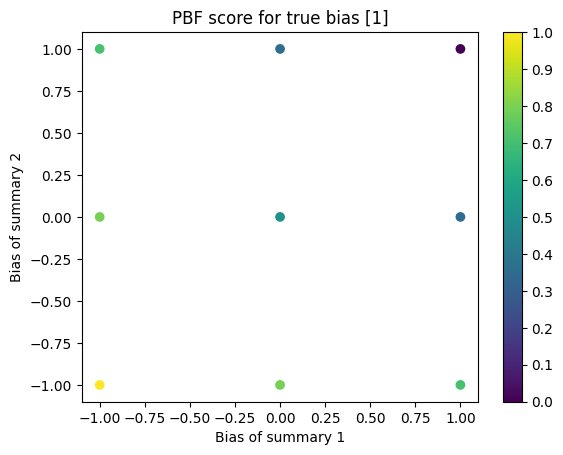

In [6]:
plot_pbf(1, 2, np.array([1]))

(27, 1, 3)
[0.5, 0.408248290463863, 0.5, 0.408248290463863, 0.28867513459481287, 0.408248290463863, 0.5, 0.408248290463863, 0.5, 0.408248290463863, 0.28867513459481287, 0.408248290463863, 0.28867513459481287, 0.0, 0.28867513459481287, 0.408248290463863, 0.28867513459481287, 0.408248290463863, 0.5, 0.408248290463863, 0.5, 0.408248290463863, 0.28867513459481287, 0.408248290463863, 0.5, 0.408248290463863, 0.5]
[[-1. -1. -1.]] 0.5
[[-1.  0. -1.]] 0.408248290463863
[[-1.  1. -1.]] 0.5
[[ 0. -1. -1.]] 0.408248290463863
[[ 0.  0. -1.]] 0.28867513459481287
[[ 0.  1. -1.]] 0.408248290463863
[[ 1. -1. -1.]] 0.5
[[ 1.  0. -1.]] 0.408248290463863
[[ 1.  1. -1.]] 0.5
[[-1. -1.  0.]] 0.408248290463863
[[-1.  0.  0.]] 0.28867513459481287
[[-1.  1.  0.]] 0.408248290463863
[[ 0. -1.  0.]] 0.28867513459481287
[[0. 0. 0.]] 0.0
[[0. 1. 0.]] 0.28867513459481287
[[ 1. -1.  0.]] 0.408248290463863
[[1. 0. 0.]] 0.28867513459481287
[[1. 1. 0.]] 0.408248290463863
[[-1. -1.  1.]] 0.5
[[-1.  0.  1.]] 0.40824829046

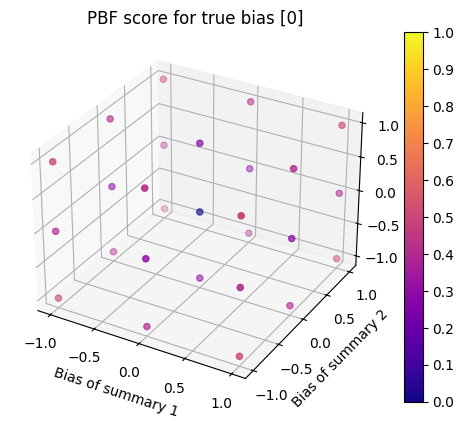

In [19]:
plot_pbf(1, 3, np.array([0]))

(27, 3, 1)
[0.5, 0.408248290463863, 0.5, 0.408248290463863, 0.28867513459481287, 0.408248290463863, 0.5, 0.408248290463863, 0.5, 0.408248290463863, 0.28867513459481287, 0.408248290463863, 0.28867513459481287, 0.0, 0.28867513459481287, 0.408248290463863, 0.28867513459481287, 0.408248290463863, 0.5, 0.408248290463863, 0.5, 0.408248290463863, 0.28867513459481287, 0.408248290463863, 0.5, 0.408248290463863, 0.5]
[[-1.]
 [-1.]
 [-1.]] 0.5
[[-1.]
 [ 0.]
 [-1.]] 0.408248290463863
[[-1.]
 [ 1.]
 [-1.]] 0.5
[[ 0.]
 [-1.]
 [-1.]] 0.408248290463863
[[ 0.]
 [ 0.]
 [-1.]] 0.28867513459481287
[[ 0.]
 [ 1.]
 [-1.]] 0.408248290463863
[[ 1.]
 [-1.]
 [-1.]] 0.5
[[ 1.]
 [ 0.]
 [-1.]] 0.408248290463863
[[ 1.]
 [ 1.]
 [-1.]] 0.5
[[-1.]
 [-1.]
 [ 0.]] 0.408248290463863
[[-1.]
 [ 0.]
 [ 0.]] 0.28867513459481287
[[-1.]
 [ 1.]
 [ 0.]] 0.408248290463863
[[ 0.]
 [-1.]
 [ 0.]] 0.28867513459481287
[[0.]
 [0.]
 [0.]] 0.0
[[0.]
 [1.]
 [0.]] 0.28867513459481287
[[ 1.]
 [-1.]
 [ 0.]] 0.408248290463863
[[1.]
 [0.]
 [0.]

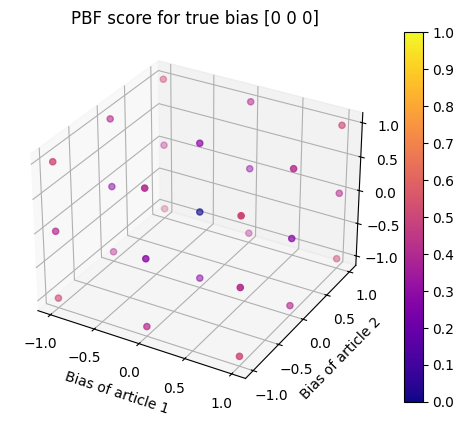

In [21]:
plot_pbf(3, 1, np.array([0, 0, 0]))

(27, 1, 3)
[1.0, 0.8660254037844386, 0.816496580927726, 0.8660254037844386, 0.7071067811865476, 0.6454972243679028, 0.816496580927726, 0.6454972243679028, 0.5773502691896257, 0.8660254037844386, 0.7071067811865476, 0.6454972243679028, 0.7071067811865476, 0.5, 0.408248290463863, 0.6454972243679028, 0.408248290463863, 0.28867513459481287, 0.816496580927726, 0.6454972243679028, 0.5773502691896257, 0.6454972243679028, 0.408248290463863, 0.28867513459481287, 0.5773502691896257, 0.28867513459481287, 0.0]
[[-1. -1. -1.]] 1.0
[[-1.  0. -1.]] 0.8660254037844386
[[-1.  1. -1.]] 0.816496580927726
[[ 0. -1. -1.]] 0.8660254037844386
[[ 0.  0. -1.]] 0.7071067811865476
[[ 0.  1. -1.]] 0.6454972243679028
[[ 1. -1. -1.]] 0.816496580927726
[[ 1.  0. -1.]] 0.6454972243679028
[[ 1.  1. -1.]] 0.5773502691896257
[[-1. -1.  0.]] 0.8660254037844386
[[-1.  0.  0.]] 0.7071067811865476
[[-1.  1.  0.]] 0.6454972243679028
[[ 0. -1.  0.]] 0.7071067811865476
[[0. 0. 0.]] 0.5
[[0. 1. 0.]] 0.408248290463863
[[ 1. -1. 

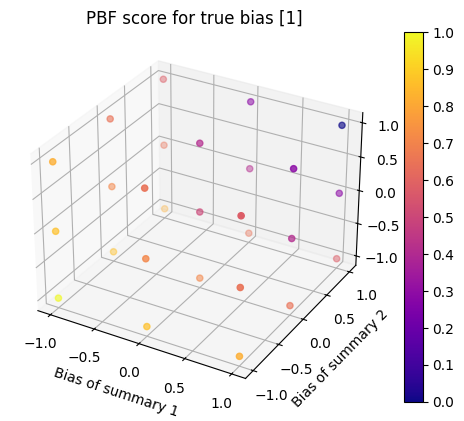

In [7]:
plot_pbf(1, 3, np.array([1]))

(19683, 3, 3)
[0.5, 0.4714045207910317, 0.5, 0.4714045207910317, 0.4409585518440984, 0.4714045207910317, 0.5, 0.4714045207910317, 0.5, 0.4714045207910317, 0.4409585518440984, 0.4714045207910317, 0.4409585518440984, 0.408248290463863, 0.4409585518440984, 0.4714045207910317, 0.4409585518440984, 0.4714045207910317, 0.5, 0.4714045207910317, 0.5, 0.4714045207910317, 0.4409585518440984, 0.4714045207910317, 0.5, 0.4714045207910317, 0.5, 0.4714045207910317, 0.4409585518440984, 0.4714045207910317, 0.4409585518440984, 0.408248290463863, 0.4409585518440984, 0.4714045207910317, 0.4409585518440984, 0.4714045207910317, 0.4409585518440984, 0.408248290463863, 0.4409585518440984, 0.408248290463863, 0.3726779962499649, 0.408248290463863, 0.4409585518440984, 0.408248290463863, 0.4409585518440984, 0.4714045207910317, 0.4409585518440984, 0.4714045207910317, 0.4409585518440984, 0.408248290463863, 0.4409585518440984, 0.4714045207910317, 0.4409585518440984, 0.4714045207910317, 0.5, 0.4714045207910317, 0.5, 0.

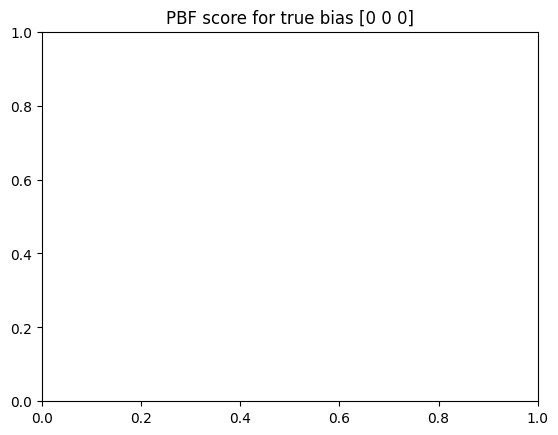

In [8]:
plot_pbf(3, 3, np.array([0, 0, 0]))

(27, 3, 1)
[1.0, 0.8660254037844386, 0.816496580927726, 0.8660254037844386, 0.7071067811865476, 0.6454972243679028, 0.816496580927726, 0.6454972243679028, 0.5773502691896257, 0.8660254037844386, 0.7071067811865476, 0.6454972243679028, 0.7071067811865476, 0.5, 0.408248290463863, 0.6454972243679028, 0.408248290463863, 0.28867513459481287, 0.816496580927726, 0.6454972243679028, 0.5773502691896257, 0.6454972243679028, 0.408248290463863, 0.28867513459481287, 0.5773502691896257, 0.28867513459481287, 0.0]
[[-1.]
 [-1.]
 [-1.]] 1.0
[[-1.]
 [ 0.]
 [-1.]] 0.8660254037844386
[[-1.]
 [ 1.]
 [-1.]] 0.816496580927726
[[ 0.]
 [-1.]
 [-1.]] 0.8660254037844386
[[ 0.]
 [ 0.]
 [-1.]] 0.7071067811865476
[[ 0.]
 [ 1.]
 [-1.]] 0.6454972243679028
[[ 1.]
 [-1.]
 [-1.]] 0.816496580927726
[[ 1.]
 [ 0.]
 [-1.]] 0.6454972243679028
[[ 1.]
 [ 1.]
 [-1.]] 0.5773502691896257
[[-1.]
 [-1.]
 [ 0.]] 0.8660254037844386
[[-1.]
 [ 0.]
 [ 0.]] 0.7071067811865476
[[-1.]
 [ 1.]
 [ 0.]] 0.6454972243679028
[[ 0.]
 [-1.]
 [ 0.]]

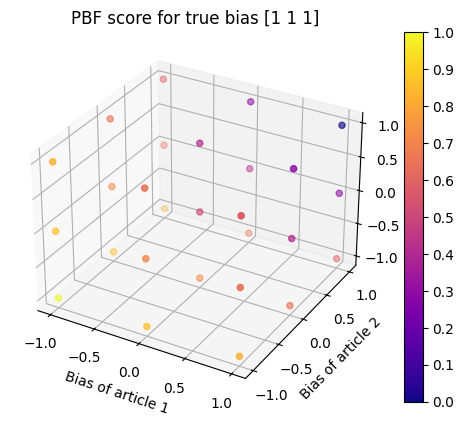

In [9]:
plot_pbf(3, 1, np.array([1, 1, 1]))

# PBI Scores

In [10]:
def plot_pbi(n_articles, n_summaries, true_bias):
  biases = np.array([-1, 0., 1.])

  # Generate all possible sets of biases (N, n_articles, n_summaries)
  all_biases = np.array(np.meshgrid(*[biases] * n_summaries * n_articles)).T.reshape(-1, n_articles, n_summaries)
  print(all_biases.shape)

  scores = []
  for bias in all_biases:
    scores.append(compute_pbi_score(true_bias, bias))

  print(scores)

  for bias, score in zip(all_biases, scores):
    print(bias, score)

  vmin = 0
  vmax = 1
  ticks = np.linspace(vmin, vmax, 11)
  
  fig = plt.figure()
  # Plot
  if n_articles == 1 and n_summaries == 2:
    im = plt.scatter(all_biases[:, 0, 0], all_biases[:, 0, 1], c=scores, vmin=vmin, vmax=vmax)
    cbar = plt.colorbar(im, ticks=ticks)
    plt.xlabel("Bias of summary 1")
    plt.ylabel("Bias of summary 2")
  elif n_summaries == 1 and n_articles == 2:
    im = plt.scatter(all_biases[:, 0, 0], all_biases[:, 1, 0], c=scores, vmin=vmin, vmax=vmax)
    cbar = plt.colorbar(im, ticks=ticks)
    plt.xlabel("Bias of article 1")
    plt.ylabel("Bias of article 2")
  elif n_summaries == 3 and n_articles == 1:
    # plot 3D
    ax = fig.add_subplot(111, projection='3d')
    sp = ax.scatter3D(all_biases[:, 0, 0], all_biases[:, 0, 1], all_biases[:, 0, 2], c=scores, cmap=cmaps['plasma'], vmin=vmin, vmax=vmax)
    plt.colorbar(sp, ticks=ticks)
    ax.set_xlabel("Bias of summary 1")
    ax.set_ylabel("Bias of summary 2")
    ax.set_zlabel("Bias of summary 3")
  elif n_summaries == 1 and n_articles == 3:
    # plot 3D
    ax = fig.add_subplot(111, projection='3d')
    sp = ax.scatter3D(all_biases[:, 0, 0], all_biases[:, 1, 0], all_biases[:, 2, 0], c=scores, cmap=cmaps['plasma'], vmin=vmin, vmax=vmax)
    plt.colorbar(sp, ticks=ticks)
    ax.set_xlabel("Bias of article 1")
    ax.set_ylabel("Bias of article 2")
    ax.set_zlabel("Bias of article 3")

  plt.title(f"PBI score for true bias {true_bias}")
  plt.show()
  plt.close()

(9, 2, 1)
[[[0]
  [1]]

 [[0]
  [1]]]
[[[0]
  [1]]

 [[1]
  [1]]]
[[[0]
  [1]]

 [[1]
  [0]]]
[[[1]
  [1]]

 [[0]
  [1]]]
[[[1]
  [1]]

 [[1]
  [1]]]
[[[1]
  [1]]

 [[1]
  [0]]]
[[[1]
  [0]]

 [[0]
  [1]]]
[[[1]
  [0]]

 [[1]
  [1]]]
[[[1]
  [0]]

 [[1]
  [0]]]
[0.0, 0.5, 0.0, 0.5, 1.0, 0.5, 0.0, 0.5, 0.0]
[[-1.]
 [-1.]] 0.0
[[-1.]
 [ 0.]] 0.5
[[-1.]
 [ 1.]] 0.0
[[ 0.]
 [-1.]] 0.5
[[0.]
 [0.]] 1.0
[[0.]
 [1.]] 0.5
[[ 1.]
 [-1.]] 0.0
[[1.]
 [0.]] 0.5
[[1.]
 [1.]] 0.0


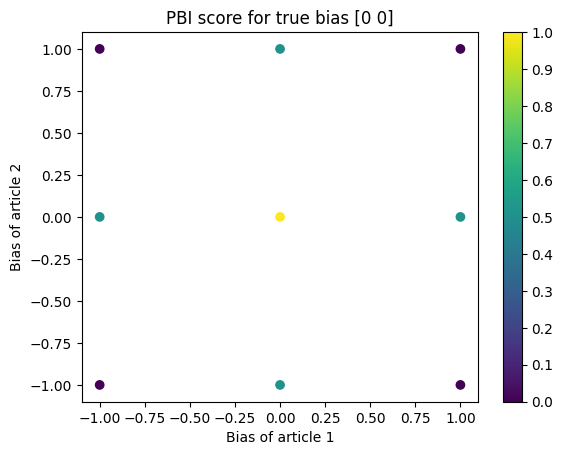

In [11]:
plot_pbi(2, 1, np.array([0, 0]))

(9, 1, 2)
[[[0 0]
  [1 1]]]
[[[0 1]
  [1 1]]]
[[[0 1]
  [1 0]]]
[[[1 0]
  [1 1]]]
[[[1 1]
  [1 1]]]
[[[1 1]
  [1 0]]]
[[[1 0]
  [0 1]]]
[[[1 1]
  [0 1]]]
[[[1 1]
  [0 0]]]
[0.0, 0.5, 0.0, 0.5, 1.0, 0.5, 0.0, 0.5, 0.0]
[[-1. -1.]] 0.0
[[-1.  0.]] 0.5
[[-1.  1.]] 0.0
[[ 0. -1.]] 0.5
[[0. 0.]] 1.0
[[0. 1.]] 0.5
[[ 1. -1.]] 0.0
[[1. 0.]] 0.5
[[1. 1.]] 0.0


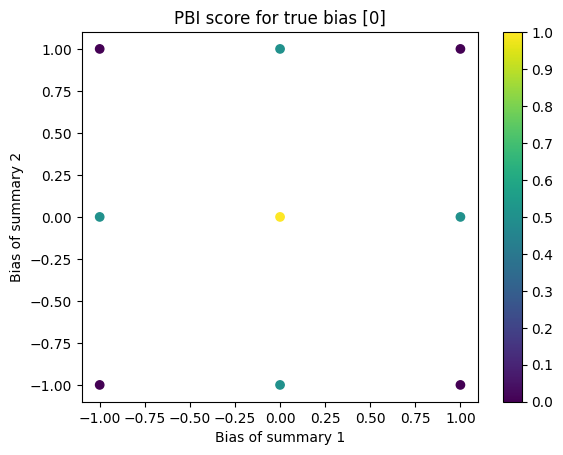

In [12]:
plot_pbi(1, 2, np.array([0]))

(9, 1, 2)
[[[0 0]
  [1 1]]]
[[[0 1]
  [1 0]]]
[[[0 1]
  [1 1]]]
[[[1 0]
  [0 1]]]
[[[1 1]
  [0 0]]]
[[[1 1]
  [0 1]]]
[[[1 0]
  [1 1]]]
[[[1 1]
  [1 0]]]
[[[1 1]
  [1 1]]]
[0.0, 0.0, 0.5, 0.0, 0.0, 0.5, 0.5, 0.5, 1.0]
[[-1. -1.]] 0.0
[[-1.  0.]] 0.0
[[-1.  1.]] 0.5
[[ 0. -1.]] 0.0
[[0. 0.]] 0.0
[[0. 1.]] 0.5
[[ 1. -1.]] 0.5
[[1. 0.]] 0.5
[[1. 1.]] 1.0


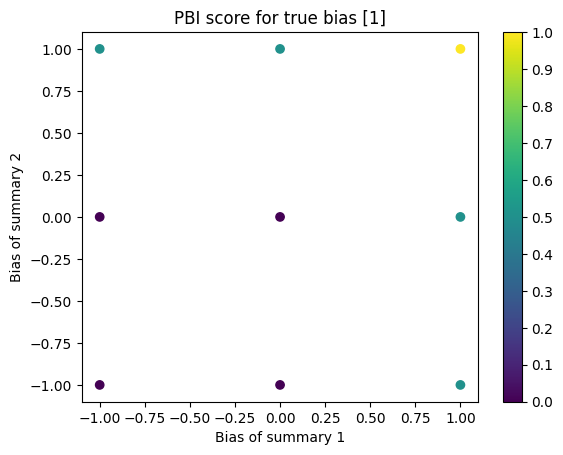

In [13]:
plot_pbi(1, 2, np.array([1]))

(9, 2, 1)
[[[0]
  [1]]

 [[0]
  [1]]]
[[[0]
  [1]]

 [[1]
  [0]]]
[[[0]
  [1]]

 [[1]
  [1]]]
[[[1]
  [0]]

 [[0]
  [1]]]
[[[1]
  [0]]

 [[1]
  [0]]]
[[[1]
  [0]]

 [[1]
  [1]]]
[[[1]
  [1]]

 [[0]
  [1]]]
[[[1]
  [1]]

 [[1]
  [0]]]
[[[1]
  [1]]

 [[1]
  [1]]]
[0.0, 0.0, 0.5, 0.0, 0.0, 0.5, 0.5, 0.5, 1.0]
[[-1.]
 [-1.]] 0.0
[[-1.]
 [ 0.]] 0.0
[[-1.]
 [ 1.]] 0.5
[[ 0.]
 [-1.]] 0.0
[[0.]
 [0.]] 0.0
[[0.]
 [1.]] 0.5
[[ 1.]
 [-1.]] 0.5
[[1.]
 [0.]] 0.5
[[1.]
 [1.]] 1.0


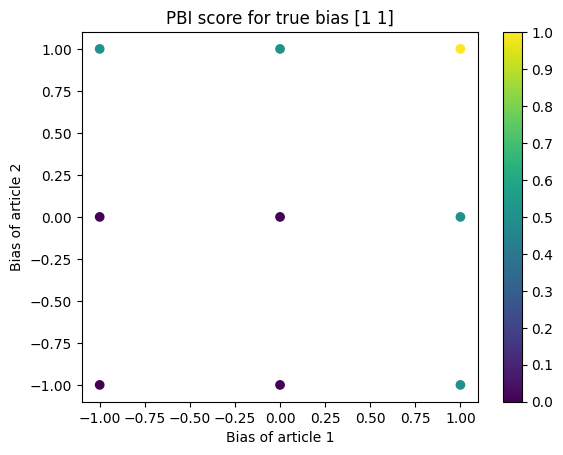

In [14]:
plot_pbi(2, 1, np.array([1, 1]))

(27, 1, 3)
[[[0 0 0]
  [1 1 1]]]
[[[0 1 0]
  [1 1 1]]]
[[[0 1 0]
  [1 0 1]]]
[[[1 0 0]
  [1 1 1]]]
[[[1 1 0]
  [1 1 1]]]
[[[1 1 0]
  [1 0 1]]]
[[[1 0 0]
  [0 1 1]]]
[[[1 1 0]
  [0 1 1]]]
[[[1 1 0]
  [0 0 1]]]
[[[0 0 1]
  [1 1 1]]]
[[[0 1 1]
  [1 1 1]]]
[[[0 1 1]
  [1 0 1]]]
[[[1 0 1]
  [1 1 1]]]
[[[1 1 1]
  [1 1 1]]]
[[[1 1 1]
  [1 0 1]]]
[[[1 0 1]
  [0 1 1]]]
[[[1 1 1]
  [0 1 1]]]
[[[1 1 1]
  [0 0 1]]]
[[[0 0 1]
  [1 1 0]]]
[[[0 1 1]
  [1 1 0]]]
[[[0 1 1]
  [1 0 0]]]
[[[1 0 1]
  [1 1 0]]]
[[[1 1 1]
  [1 1 0]]]
[[[1 1 1]
  [1 0 0]]]
[[[1 0 1]
  [0 1 0]]]
[[[1 1 1]
  [0 1 0]]]
[[[1 1 1]
  [0 0 0]]]
[0.0, 0.33333333333333326, 0.0, 0.33333333333333326, 0.6666666666666667, 0.33333333333333326, 0.0, 0.33333333333333326, 0.0, 0.33333333333333326, 0.6666666666666667, 0.33333333333333326, 0.6666666666666667, 1.0, 0.6666666666666667, 0.33333333333333326, 0.6666666666666667, 0.33333333333333326, 0.0, 0.33333333333333326, 0.0, 0.33333333333333326, 0.6666666666666667, 0.33333333333333326, 0.0, 0.3

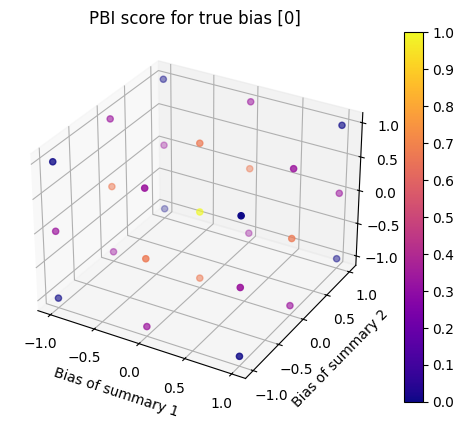

In [15]:
plot_pbi(1, 3, np.array([0]))

(27, 3, 1)
[[[0]
  [1]]

 [[0]
  [1]]

 [[0]
  [1]]]
[[[0]
  [1]]

 [[1]
  [1]]

 [[0]
  [1]]]
[[[0]
  [1]]

 [[1]
  [0]]

 [[0]
  [1]]]
[[[1]
  [1]]

 [[0]
  [1]]

 [[0]
  [1]]]
[[[1]
  [1]]

 [[1]
  [1]]

 [[0]
  [1]]]
[[[1]
  [1]]

 [[1]
  [0]]

 [[0]
  [1]]]
[[[1]
  [0]]

 [[0]
  [1]]

 [[0]
  [1]]]
[[[1]
  [0]]

 [[1]
  [1]]

 [[0]
  [1]]]
[[[1]
  [0]]

 [[1]
  [0]]

 [[0]
  [1]]]
[[[0]
  [1]]

 [[0]
  [1]]

 [[1]
  [1]]]
[[[0]
  [1]]

 [[1]
  [1]]

 [[1]
  [1]]]
[[[0]
  [1]]

 [[1]
  [0]]

 [[1]
  [1]]]
[[[1]
  [1]]

 [[0]
  [1]]

 [[1]
  [1]]]
[[[1]
  [1]]

 [[1]
  [1]]

 [[1]
  [1]]]
[[[1]
  [1]]

 [[1]
  [0]]

 [[1]
  [1]]]
[[[1]
  [0]]

 [[0]
  [1]]

 [[1]
  [1]]]
[[[1]
  [0]]

 [[1]
  [1]]

 [[1]
  [1]]]
[[[1]
  [0]]

 [[1]
  [0]]

 [[1]
  [1]]]
[[[0]
  [1]]

 [[0]
  [1]]

 [[1]
  [0]]]
[[[0]
  [1]]

 [[1]
  [1]]

 [[1]
  [0]]]
[[[0]
  [1]]

 [[1]
  [0]]

 [[1]
  [0]]]
[[[1]
  [1]]

 [[0]
  [1]]

 [[1]
  [0]]]
[[[1]
  [1]]

 [[1]
  [1]]

 [[1]
  [0]]]
[[[1]
  [1]]

 [[1]
  [

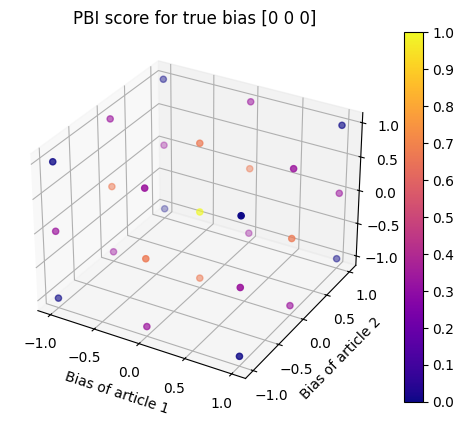

In [16]:
plot_pbi(3, 1, np.array([0, 0, 0]))

(27, 1, 3)
[[[0 0 0]
  [1 1 1]]]
[[[0 1 0]
  [1 0 1]]]
[[[0 1 0]
  [1 1 1]]]
[[[1 0 0]
  [0 1 1]]]
[[[1 1 0]
  [0 0 1]]]
[[[1 1 0]
  [0 1 1]]]
[[[1 0 0]
  [1 1 1]]]
[[[1 1 0]
  [1 0 1]]]
[[[1 1 0]
  [1 1 1]]]
[[[0 0 1]
  [1 1 0]]]
[[[0 1 1]
  [1 0 0]]]
[[[0 1 1]
  [1 1 0]]]
[[[1 0 1]
  [0 1 0]]]
[[[1 1 1]
  [0 0 0]]]
[[[1 1 1]
  [0 1 0]]]
[[[1 0 1]
  [1 1 0]]]
[[[1 1 1]
  [1 0 0]]]
[[[1 1 1]
  [1 1 0]]]
[[[0 0 1]
  [1 1 1]]]
[[[0 1 1]
  [1 0 1]]]
[[[0 1 1]
  [1 1 1]]]
[[[1 0 1]
  [0 1 1]]]
[[[1 1 1]
  [0 0 1]]]
[[[1 1 1]
  [0 1 1]]]
[[[1 0 1]
  [1 1 1]]]
[[[1 1 1]
  [1 0 1]]]
[[[1 1 1]
  [1 1 1]]]
[0.0, 0.0, 0.33333333333333326, 0.0, 0.0, 0.33333333333333326, 0.33333333333333326, 0.33333333333333326, 0.6666666666666667, 0.0, 0.0, 0.33333333333333326, 0.0, 0.0, 0.33333333333333326, 0.33333333333333326, 0.33333333333333326, 0.6666666666666667, 0.33333333333333326, 0.33333333333333326, 0.6666666666666667, 0.33333333333333326, 0.33333333333333326, 0.6666666666666667, 0.6666666666666667, 0.

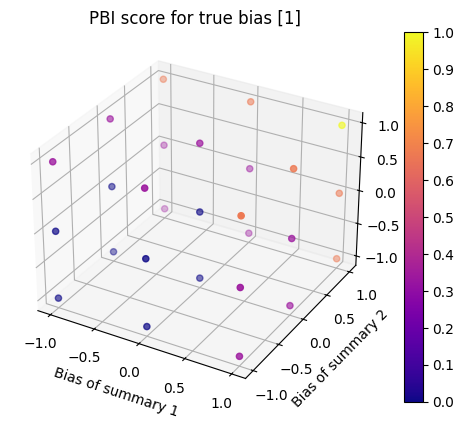

In [17]:
plot_pbi(1, 3, np.array([1]))

(27, 3, 1)
[[[0]
  [1]]

 [[0]
  [1]]

 [[0]
  [1]]]
[[[0]
  [1]]

 [[1]
  [0]]

 [[0]
  [1]]]
[[[0]
  [1]]

 [[1]
  [1]]

 [[0]
  [1]]]
[[[1]
  [0]]

 [[0]
  [1]]

 [[0]
  [1]]]
[[[1]
  [0]]

 [[1]
  [0]]

 [[0]
  [1]]]
[[[1]
  [0]]

 [[1]
  [1]]

 [[0]
  [1]]]
[[[1]
  [1]]

 [[0]
  [1]]

 [[0]
  [1]]]
[[[1]
  [1]]

 [[1]
  [0]]

 [[0]
  [1]]]
[[[1]
  [1]]

 [[1]
  [1]]

 [[0]
  [1]]]
[[[0]
  [1]]

 [[0]
  [1]]

 [[1]
  [0]]]
[[[0]
  [1]]

 [[1]
  [0]]

 [[1]
  [0]]]
[[[0]
  [1]]

 [[1]
  [1]]

 [[1]
  [0]]]
[[[1]
  [0]]

 [[0]
  [1]]

 [[1]
  [0]]]
[[[1]
  [0]]

 [[1]
  [0]]

 [[1]
  [0]]]
[[[1]
  [0]]

 [[1]
  [1]]

 [[1]
  [0]]]
[[[1]
  [1]]

 [[0]
  [1]]

 [[1]
  [0]]]
[[[1]
  [1]]

 [[1]
  [0]]

 [[1]
  [0]]]
[[[1]
  [1]]

 [[1]
  [1]]

 [[1]
  [0]]]
[[[0]
  [1]]

 [[0]
  [1]]

 [[1]
  [1]]]
[[[0]
  [1]]

 [[1]
  [0]]

 [[1]
  [1]]]
[[[0]
  [1]]

 [[1]
  [1]]

 [[1]
  [1]]]
[[[1]
  [0]]

 [[0]
  [1]]

 [[1]
  [1]]]
[[[1]
  [0]]

 [[1]
  [0]]

 [[1]
  [1]]]
[[[1]
  [0]]

 [[1]
  [

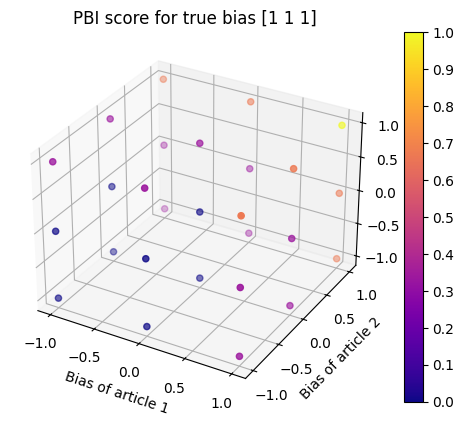

In [18]:
plot_pbi(3, 1, np.array([1, 1, 1]))